# 02 - Preprocessing

Based on the findings of `01_eda`: remove duplicates and train/test leakage, split off a validation set,
and save the images in two versions (with and without the black border) for the margin removal experiment.

## 1. Imports

In [ ]:
from pathlib import Path
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import imagehash
from scipy import ndimage
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

## 2. Paths

In [2]:
DATA_DIR = Path("..") / "data"
PROCESSED_DIR = DATA_DIR / "processed"

## 3. Image table and hashes

Same as in `01_eda`: one row per image with its split, label and perceptual hash.

In [3]:
paths = sorted(DATA_DIR.glob("Training/*/*.jpg")) + sorted(DATA_DIR.glob("Testing/*/*.jpg"))

df = pd.DataFrame({"path": paths})
df["split"] = [p.parent.parent.name for p in paths]
df["label"] = [p.parent.name for p in paths]
df["hash"] = [str(imagehash.phash(Image.open(p))) for p in tqdm(paths)]
df.head()

100%|██████████| 7200/7200 [00:10<00:00, 656.11it/s]


,path,split,label,hash
0,..\data\Training\glioma\Tr-gl_1.jpg,Training,glioma,d01f2b693cb46d70
1,..\data\Training\glioma\Tr-gl_10.jpg,Training,glioma,c09e6b8d2f8b6c2c
2,..\data\Training\glioma\Tr-gl_100.jpg,Training,glioma,c03f2f3d36e43292
3,..\data\Training\glioma\Tr-gl_1000.jpg,Training,glioma,c0967e493e8e2d6c
4,..\data\Training\glioma\Tr-gl_1001.jpg,Training,glioma,93cf6c906166b63c


In [4]:
counts_before = pd.crosstab(df["label"], df["split"], margins=True, margins_name="total")
counts_before

split,Testing,Training,total
label,,,
glioma,400,1400,1800
meningioma,400,1400,1800
notumor,400,1400,1800
pituitary,400,1400,1800
total,1600,5600,7200


## 4. Remove duplicates, leakage and banners

### 4.1 Label conflicts

Images whose hash appears with more than one label; dropped.

In [5]:
labels_per_hash = df.groupby("hash")["label"].nunique()
conflict_hashes = labels_per_hash[labels_per_hash > 1].index

df = df[~df["hash"].isin(conflict_hashes)]
len(df)

7197

### 4.2 Leakage

Training images whose hash also appears in the test set are dropped.

In [6]:
test_hashes = df.loc[df["split"] == "Testing", "hash"]

df = df[~((df["split"] == "Training") & df["hash"].isin(test_hashes))]
len(df)

6713

### 4.3 Duplicates within a split

Keep the first image of every duplicate group, separately for train and test.

In [7]:
df = df.drop_duplicates(subset=["split", "hash"]).reset_index(drop=True)
len(df)

6211

### 4.4 Website banners

Some notumor images have a blue Medscape banner. A pixel counts as blue when its blue value is at least 40 higher than red and green.
An image has a banner when one row of pixels is more than 30% blue.

In [8]:
has_banner = np.zeros(len(df), dtype=bool)

for i, p in enumerate(tqdm(df["path"])):
    img = np.asarray(Image.open(p).convert("RGB")).astype(int)
    blue = (img[:, :, 2] - np.maximum(img[:, :, 0], img[:, :, 1])) > 40
    has_banner[i] = blue.mean(axis=1).max() > 0.3

df.loc[has_banner, ["path", "split", "label"]]

100%|██████████| 6211/6211 [00:28<00:00, 218.84it/s]


,path,split,label
2752,..\data\Training\notumor\Tr-no_1104.jpg,Training,notumor
2807,..\data\Training\notumor\Tr-no_1177.jpg,Training,notumor
2936,..\data\Training\notumor\Tr-no_1373.jpg,Training,notumor
2956,..\data\Training\notumor\Tr-no_151.jpg,Training,notumor
2973,..\data\Training\notumor\Tr-no_179.jpg,Training,notumor
5508,..\data\Testing\notumor\Te-no_1.jpg,Testing,notumor
5567,..\data\Testing\notumor\Te-no_156.jpg,Testing,notumor
5644,..\data\Testing\notumor\Te-no_234.jpg,Testing,notumor
5682,..\data\Testing\notumor\Te-no_279.jpg,Testing,notumor
5700,..\data\Testing\notumor\Te-no_297.jpg,Testing,notumor


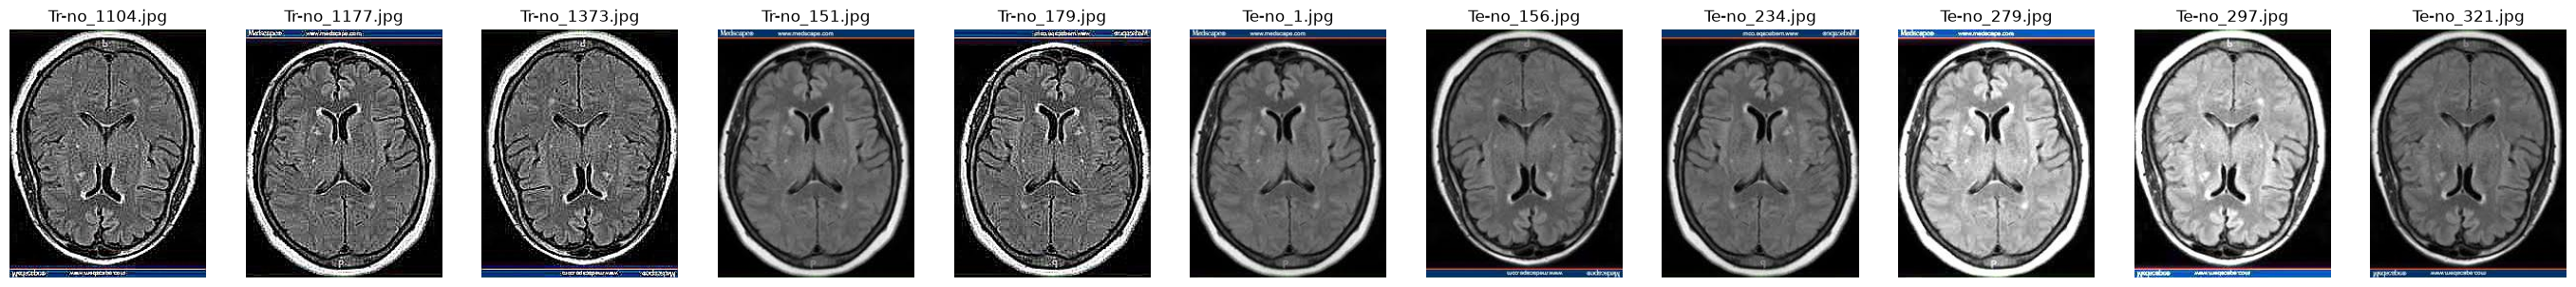

In [9]:
banners = df[has_banner]

fig, axes = plt.subplots(1, len(banners), figsize=(2.5 * len(banners), 3))
for ax, path in zip(axes, banners["path"]):
    ax.imshow(Image.open(path))
    ax.set_title(path.name)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [10]:
df = df[~has_banner].reset_index(drop=True)
len(df)

6200

### 4.5 Before and after

In [11]:
counts_after = pd.crosstab(df["label"], df["split"], margins=True, margins_name="total")
pd.concat([counts_before, counts_after], axis=1, keys=["before", "after"])

before                  after               
split      Testing Training total Testing Training total
label                                                   
glioma         400     1400  1800     381     1393  1774
meningioma     400     1400  1800     389     1277  1666
notumor        400     1400  1800     297      715  1012
pituitary      400     1400  1800     400     1348  1748
total         1600     5600  7200    1467     4733  6200

### 4.6 Conclusions

- 7,200 to 6,200 images: 4,733 train and 1,467 test.
- Notumor lost the most: 1,400 to 715 in train and 400 to 297 in test.
- Train and test no longer share any image (by hash), so the test score will be honest.
- All 11 images with a website banner are removed, so the model cannot use the banner as a shortcut.
  Limitation: a banner that was saved in grayscale has no blue and would not be found.
- The classes are no longer balanced: notumor has about half as many training images. Class weights in `03_training` correct for this.

## 5. Validation split

### 5.1 Split off 15% of train

`stratify` keeps the class proportions the same in train and validation.

In [12]:
df["split"] = df["split"].replace({"Training": "train", "Testing": "test"})

train_rows = df[df["split"] == "train"]
_, val_rows = train_test_split(train_rows, test_size=0.15, stratify=train_rows["label"], random_state=42)
df.loc[val_rows.index, "split"] = "val"

pd.crosstab(df["label"], df["split"], margins=True, margins_name="total")[["train", "val", "test", "total"]]

split,train,val,test,total
label,,,,
glioma,1184,209,381,1774
meningioma,1085,192,389,1666
notumor,608,107,297,1012
pituitary,1146,202,400,1748
total,4023,710,1467,6200


### 5.2 Check the class proportions


In [13]:
pd.crosstab(df["label"], df["split"], normalize="columns").round(3)[["train", "val", "test"]]

split,train,val,test
label,,,
glioma,0.294,0.294,0.260
meningioma,0.270,0.270,0.265
notumor,0.151,0.151,0.202
pituitary,0.285,0.285,0.273


### 5.3 Conclusions

- Final split: 4,023 train, 710 validation and 1,467 test images.
- Train and validation have the same class proportions, thanks to `stratify`.
- The test set has relatively more notumor (20.2%), because fewer test duplicates were removed. That is fine: the test set is only used at the end.

## 6. Crop the black border

### 6.1 Method

Keep only the largest bright area in the image (the head) and cut the image around it.
Small text and lines in the corners are ignored.

### 6.2 Examples

Chosen on purpose: two normal tumor images, two notumor images with text in the corners, and a wide notumor image.

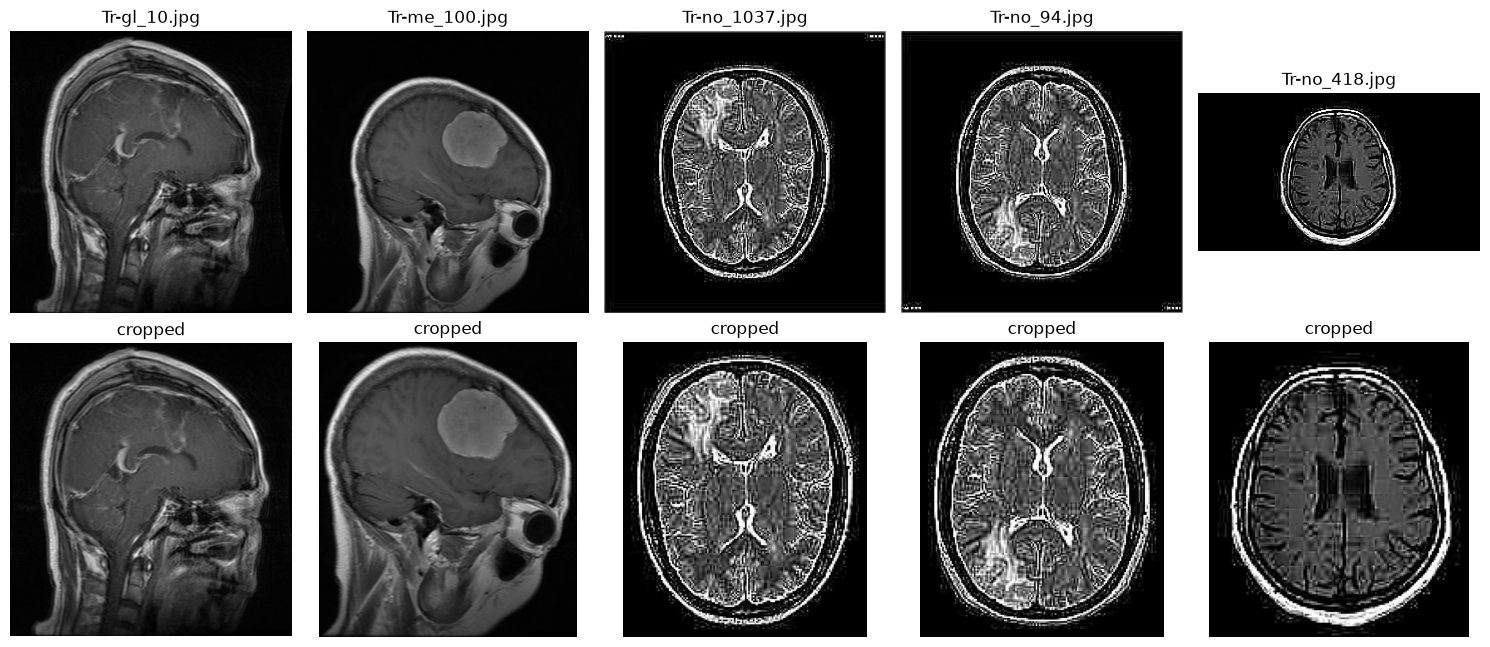

In [14]:
examples = [
    DATA_DIR / "Training" / "glioma" / "Tr-gl_10.jpg",
    DATA_DIR / "Training" / "meningioma" / "Tr-me_100.jpg",
    DATA_DIR / "Training" / "notumor" / "Tr-no_1037.jpg",
    DATA_DIR / "Training" / "notumor" / "Tr-no_94.jpg",
    DATA_DIR / "Training" / "notumor" / "Tr-no_418.jpg",
]

fig, axes = plt.subplots(2, len(examples), figsize=(3 * len(examples), 6.5))
for i, path in enumerate(examples):
    img = np.asarray(Image.open(path).convert("L"))
    mask = ndimage.binary_dilation(img >= 15, iterations=5)
    labeled, _ = ndimage.label(mask)
    largest = np.bincount(labeled.ravel())[1:].argmax() + 1
    box = ndimage.find_objects(labeled)[largest - 1]

    axes[0, i].imshow(img, cmap="gray")
    axes[0, i].set_title(path.name)
    axes[1, i].imshow(img[box], cmap="gray")
    axes[1, i].set_title("cropped")
for ax in axes.flat:
    ax.axis("off")
plt.tight_layout()
plt.show()

### 6.3 Conclusions

- The crop removes the black border and keeps the whole head, including the skull.
- Text and markers in the corners no longer block the crop.
- Images where the head already fills the frame stay (almost) the same, which is correct.

## 7. Save processed images

### 7.1 Grayscale, brightness, crop, pad and resize

Every image is saved twice: `full` (with the border) and `cropped`.
Every image gets the same average brain brightness (100), because notumor images were clearly brighter (see `01_eda`).
Before resizing to 224x224, black padding makes the image square, so the head is not stretched.
This matters because many notumor images are not square (see `01_eda`).
Images are saved as PNG, which does not lose quality like JPG.

In [20]:
SIZE = 224

for version in ["full", "cropped"]:
    for split in ["train", "val", "test"]:
        for label in df["label"].unique():
            (PROCESSED_DIR / version / split / label).mkdir(parents=True, exist_ok=True)

for path, split, label in tqdm(zip(df["path"], df["split"], df["label"]), total=len(df)):
    img = np.asarray(Image.open(path).convert("L"))

    mask = ndimage.binary_dilation(img >= 15, iterations=5)
    labeled, _ = ndimage.label(mask)
    largest = np.bincount(labeled.ravel())[1:].argmax() + 1
    box = ndimage.find_objects(labeled)[largest - 1]

    brain_mean = img[img >= 15].mean()
    img = np.clip(img * (100 / brain_mean), 0, 255).astype(np.uint8)

    for version, version_img in [("full", img), ("cropped", img[box])]:
        h, w = version_img.shape
        side = max(h, w)
        square = np.zeros((side, side), dtype=np.uint8)
        top = (side - h) // 2
        left = (side - w) // 2
        square[top:top + h, left:left + w] = version_img

        resized = Image.fromarray(square).resize((SIZE, SIZE), Image.LANCZOS)
        resized.save(PROCESSED_DIR / version / split / label / (path.stem + ".png"))

100%|██████████| 6200/6200 [01:38<00:00, 62.76it/s] 


### 7.2 Check the saved images


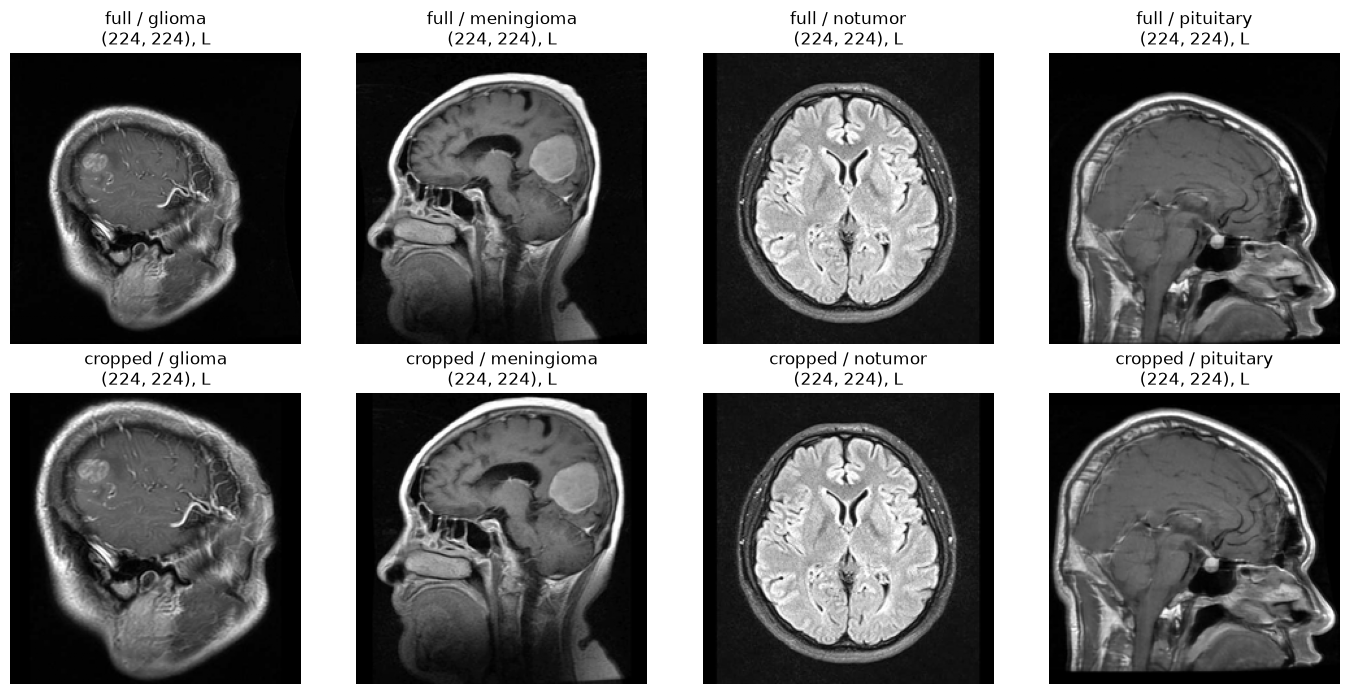

In [21]:
check = df.groupby("label").sample(n=1, random_state=1)

fig, axes = plt.subplots(2, len(check), figsize=(3.5 * len(check), 7))
for i, (path, split, label) in enumerate(zip(check["path"], check["split"], check["label"])):
    for row, version in enumerate(["full", "cropped"]):
        saved = Image.open(PROCESSED_DIR / version / split / label / (path.stem + ".png"))
        axes[row, i].imshow(saved, cmap="gray", vmin=0, vmax=255)
        axes[row, i].set_title(f"{version} / {label}\n{saved.size}, {saved.mode}")
        axes[row, i].axis("off")
plt.tight_layout()
plt.show()

In [22]:
brightness = np.zeros(len(df))

for i, (path, split, label) in enumerate(zip(df["path"], df["split"], df["label"])):
    saved = np.asarray(Image.open(PROCESSED_DIR / "cropped" / split / label / (path.stem + ".png")))
    brightness[i] = saved[saved >= 15].mean()

df["brightness"] = brightness
df.groupby("label")["brightness"].median()

label
glioma        97.569909
meningioma    98.470250
notumor       98.735110
pituitary     97.280140
Name: brightness, dtype: float64

### 7.3 Save the split table

One row per image: file name, split, label and hash. `03_training` can use it to check the folders, and it records exactly which images were used.

In [23]:
splits = pd.DataFrame({
    "file": [p.stem + ".png" for p in df["path"]],
    "split": df["split"],
    "label": df["label"],
    "hash": df["hash"],
    "source": [str(p) for p in df["path"]],
})
splits.to_csv(PROCESSED_DIR / "splits.csv", index=False)
splits.head()

,file,split,label,hash,source
0,Tr-gl_1.png,train,glioma,d01f2b693cb46d70,..\data\Training\glioma\Tr-gl_1.jpg
1,Tr-gl_10.png,val,glioma,c09e6b8d2f8b6c2c,..\data\Training\glioma\Tr-gl_10.jpg
2,Tr-gl_100.png,train,glioma,c03f2f3d36e43292,..\data\Training\glioma\Tr-gl_100.jpg
3,Tr-gl_1000.png,train,glioma,c0967e493e8e2d6c,..\data\Training\glioma\Tr-gl_1000.jpg
4,Tr-gl_1001.png,train,glioma,93cf6c906166b63c,..\data\Training\glioma\Tr-gl_1001.jpg


### 7.4 Conclusions

- Two versions of 6,200 images each, all 224x224 grayscale.
- Every class now has the same average brain brightness (before: 68-99, see `01_eda`), so brightness is no longer a shortcut.
  A small difference in contrast type remains (bright fluid in some notumor scans), which cannot be removed without losing real information.
- Non-square images are padded, not stretched, so no class gets distorted heads.
- Limitation: 34% of the cropped notumor images are smaller than 224 px and get upscaled, so they are a bit blurrier than the tumor images.
  Random blur as augmentation in `03_training` (for all classes) makes sharpness less useful as a shortcut.
- Model normalization and augmentation are not done here: they happen during training in `03_training`.

## 8. Version 2: split by class and source

In `04_evaluation` the first model (v1) turned out to miss many tumors from the second source: in the original training folder
all gliomas came from the main source (512x512), so the model never saw a glioma from another source.

For v2, all 6,200 cleaned images are put together and split again, so that every split gets images from both sources.
The images themselves stay the same, only the split changes. v1 is kept as it is, to compare.

### 8.1 Source of every image

Like in `04_evaluation`, the original size is used as a rough sign of the source: 512x512 = main source, anything else = other source.

In [ ]:
df["source_group"] = np.where([Image.open(p).size == (512, 512) for p in df["path"]], "512", "other")
df["strata"] = df["label"] + "_" + df["source_group"]

pd.crosstab(df["label"], df["source_group"])

### 8.2 New split

70% train, 15% validation, 15% test, stratified on class and source together (`strata`, for example `glioma_other`).
So every split gets the same mix of classes and sources. First the test set is split off, then the validation set.

In [ ]:
rest_v2, test_v2 = train_test_split(df, test_size=0.15, stratify=df["strata"], random_state=42)
train_v2, val_v2 = train_test_split(rest_v2, test_size=0.15 / 0.85, stratify=rest_v2["strata"], random_state=42)

df["split_v2"] = "train"
df.loc[val_v2.index, "split_v2"] = "val"
df.loc[test_v2.index, "split_v2"] = "test"

pd.crosstab(df["strata"], df["split_v2"], margins=True, margins_name="total")[["train", "val", "test", "total"]]

### 8.3 Save version 2

Only the cropped version, because that is the final model. The processed images from section 7 are copied into the new folders,
so nothing has to be processed again. The split table also keeps the v1 split (`split_v1`), which `04_evaluation` needs for a fair comparison.

In [ ]:
PROCESSED_V2_DIR = DATA_DIR / "processed_v2"

for split in ["train", "val", "test"]:
    for label in df["label"].unique():
        (PROCESSED_V2_DIR / "cropped" / split / label).mkdir(parents=True, exist_ok=True)

for path, split, split_v2, label in tqdm(zip(df["path"], df["split"], df["split_v2"], df["label"]), total=len(df)):
    file = path.stem + ".png"
    shutil.copy(PROCESSED_DIR / "cropped" / split / label / file, PROCESSED_V2_DIR / "cropped" / split_v2 / label / file)

splits_v2 = pd.DataFrame({
    "file": [p.stem + ".png" for p in df["path"]],
    "split_v2": df["split_v2"],
    "split_v1": df["split"],
    "label": df["label"],
    "source_group": df["source_group"],
    "source": [str(p) for p in df["path"]],
})
splits_v2.to_csv(PROCESSED_V2_DIR / "splits_v2.csv", index=False)

len(list((PROCESSED_V2_DIR / "cropped").glob("*/*/*.png")))

### 8.4 Conclusions

- v2: 4,339 train, 931 validation and 930 test images, with the same mix of classes and sources in every split.
- Training now has 44 gliomas and 95 meningiomas from the other source. In v1 that was 0 gliomas.
- The other-source tumors are still a small group (63 gliomas and 135 meningiomas in total),
  so the test results for that group will be based on few images (9 gliomas, 20 meningiomas).
- The v2 test set is not the official Kaggle test set anymore. For a fair comparison with v1, `04_evaluation` only uses
  the v2 test images that were also in the original test folder: neither model has seen those.